In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df=pd.read_csv("Advertising.csv")

In [13]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [14]:
df.drop("Unnamed: 0",inplace=True,axis=1)

In [15]:
X=df[["TV","Radio","Newspaper"]]
y=df["Sales"]

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [17]:
from sklearn.linear_model import Ridge
model=Ridge(alpha=10)

In [18]:
model.fit(X_train,y_train)

Ridge(alpha=10)

In [19]:
print("Alpha=10")
print(pd.Series(model.coef_,index=X.columns))

Alpha=10
TV           0.044730
Radio        0.189131
Newspaper    0.002779
dtype: float64


In [20]:
y_pred=model.predict(X_test)

In [21]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

0.8994388046339132


Text(0.5, 1.0, 'Ridge regression at alpha =10')

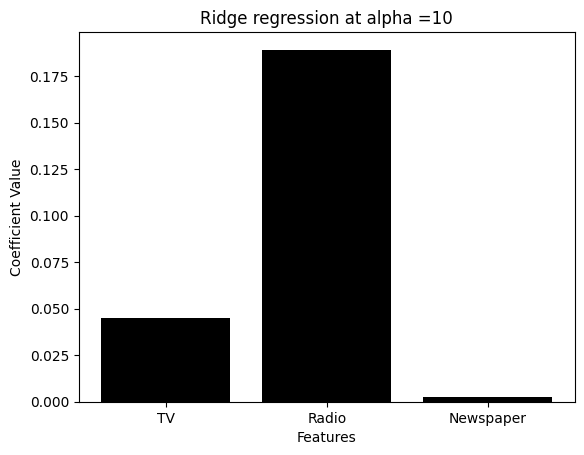

In [22]:
coeff=model.coef_
plt.bar(X.columns,coeff,color="Black")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.title("Ridge regression at alpha =10")

Alpha=0.01| Coefficient=[0.04472952 0.18919499 0.00276113]
Alpha=0.012648552168552958| Coefficient=[0.04472952 0.18919497 0.00276114]
Alpha=0.015998587196060583| Coefficient=[0.04472952 0.18919495 0.00276114]
Alpha=0.020235896477251575| Coefficient=[0.04472952 0.18919493 0.00276115]
Alpha=0.025595479226995357| Coefficient=[0.04472952 0.18919489 0.00276116]
Alpha=0.032374575428176434| Coefficient=[0.04472952 0.18919485 0.00276117]
Alpha=0.040949150623804255| Coefficient=[0.04472952 0.18919479 0.00276119]
Alpha=0.05179474679231213| Coefficient=[0.04472952 0.18919472 0.00276121]
Alpha=0.0655128556859551| Coefficient=[0.04472952 0.18919464 0.00276123]
Alpha=0.08286427728546843| Coefficient=[0.04472952 0.18919453 0.00276126]
Alpha=0.10481131341546858| Coefficient=[0.04472952 0.18919439 0.0027613 ]
Alpha=0.13257113655901095| Coefficient=[0.04472952 0.18919421 0.00276135]


Alpha=0.16768329368110083| Coefficient=[0.04472952 0.18919399 0.00276141]
Alpha=0.21209508879201905| Coefficient=[0.04472952 0.1891937  0.00276149]
Alpha=0.2682695795279726| Coefficient=[0.04472952 0.18919335 0.00276159]
Alpha=0.33932217718953295| Coefficient=[0.04472952 0.18919289 0.00276171]
Alpha=0.42919342601287785| Coefficient=[0.04472952 0.18919232 0.00276187]
Alpha=0.5428675439323859| Coefficient=[0.04472952 0.1891916  0.00276207]
Alpha=0.6866488450043002| Coefficient=[0.04472953 0.18919068 0.00276232]
Alpha=0.8685113737513529| Coefficient=[0.04472953 0.18918952 0.00276264]
Alpha=1.0985411419875584| Coefficient=[0.04472953 0.18918806 0.00276304]
Alpha=1.3894954943731375| Coefficient=[0.04472954 0.18918621 0.00276355]
Alpha=1.757510624854793| Coefficient=[0.04472954 0.18918386 0.0027642 ]
Alpha=2.2229964825261956| Coefficient=[0.04472955 0.1891809  0.00276502]
Alpha=2.8117686979742307| Coefficient=[0.04472955 0.18917715 0.00276605]
Alpha=3.5564803062231287| Coefficient=[0.0447295

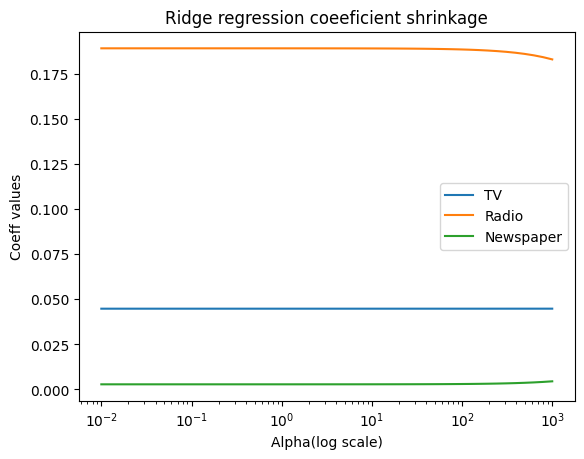

In [23]:
alphas=np.logspace(-2,3,50)
coeff_path=[]
for alph in alphas:
    model=Ridge(alpha=alph)
    model.fit(X_train,y_train)
    coeff_path.append(model.coef_)
    print(f"Alpha={alph}| Coefficient={model.coef_}")
coeff_path=np.array(coeff_path)
plt.plot(alphas,coeff_path)
plt.xscale("log")
plt.xlabel("Alpha(log scale)")
plt.ylabel("Coeff values")
plt.title("Ridge regression coeeficient shrinkage")
plt.legend(X.columns)

In [24]:

print()